# 01 — Data Exploration

Load the merged market dataset (SPY OHLCV, VIX, Treasury-yield proxies) and examine the basic statistical properties that motivate the study: fat-tailed returns and volatility clustering.

In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({"figure.figsize": (11, 5), "figure.dpi": 100,
                     "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.float_format", lambda v: f"{v:.4f}")


In [2]:
from src.data import build_market_dataset, summarize_dataset

market = build_market_dataset()
print(summarize_dataset(market))
market.tail(3)

Observations: 4,177
Date range:   2010-01-04 to 2026-08-12
Columns:      open, high, low, close, adj_close, volume, vix, yield_10y, yield_3m
Missing values per column:
open         0
high         0
low          0
close        0
adj_close    0
volume       0
vix          0
yield_10y    0
yield_3m     0


,open,high,low,close,adj_close,volume,vix,yield_10y,yield_3m
Date,,,,,,,,,
2026-08-10,772.6000,775.0500,771.6200,773.0300,773.0300,39249500,15.4600,4.6990,3.7180
2026-08-11,774.5300,774.6100,769.2000,770.5600,770.5600,36740600,15.2800,4.6840,3.7300
2026-08-12,774.7100,774.8700,771.2900,772.4700,772.4700,27220388,14.4400,4.6820,3.7070


## SPY price history and VIX

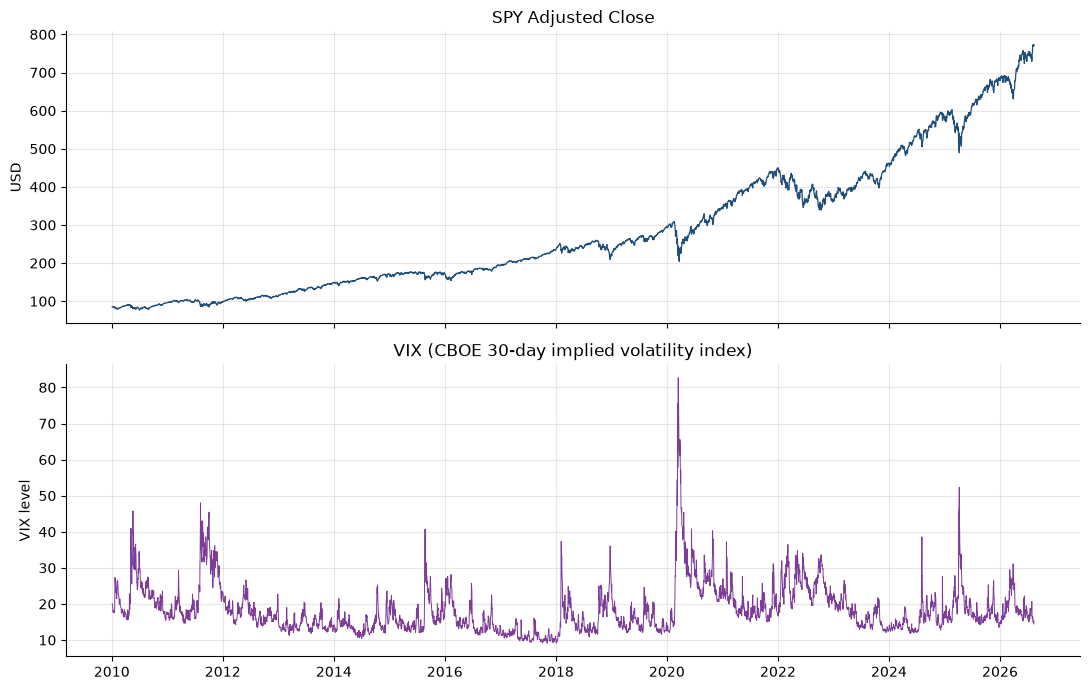

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(market.index, market["adj_close"], color="#1f4e79", lw=0.9)
axes[0].set_title("SPY Adjusted Close")
axes[0].set_ylabel("USD")
axes[1].plot(market.index, market["vix"], color="#7d3c98", lw=0.7)
axes[1].set_title("VIX (CBOE 30-day implied volatility index)")
axes[1].set_ylabel("VIX level")
plt.tight_layout()

## Return distribution

Daily log returns are far from Gaussian: strongly negative skew and large excess kurtosis mean extreme moves occur much more often than a normal distribution implies.

mean:            0.00053
std:             0.01079
skewness:        -0.556
excess kurtosis: 12.36
annualized vol:  17.1%


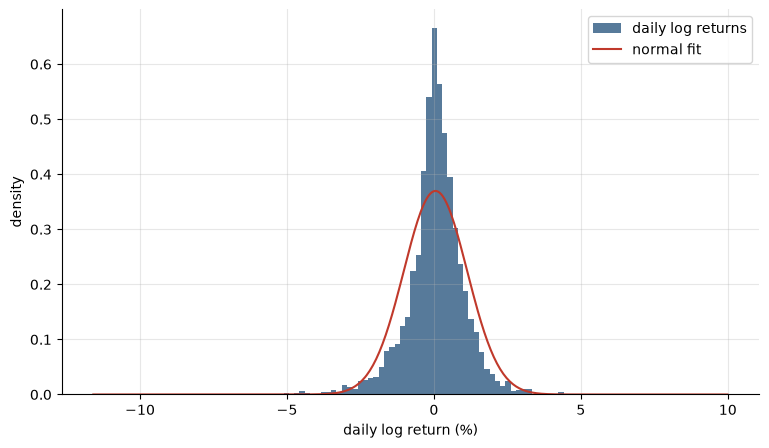

In [4]:
from src.features import log_returns

r = log_returns(market["adj_close"]).dropna()
print(f"mean:            {r.mean():.5f}")
print(f"std:             {r.std():.5f}")
print(f"skewness:        {stats.skew(r):.3f}")
print(f"excess kurtosis: {stats.kurtosis(r):.2f}")
print(f"annualized vol:  {r.std() * np.sqrt(252):.1%}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(r * 100, bins=120, density=True, color="#1f4e79", alpha=0.75, label="daily log returns")
x = np.linspace(r.min(), r.max(), 400)
ax.plot(x * 100, stats.norm.pdf(x, r.mean(), r.std()) / 100, color="#c0392b", label="normal fit")
ax.set_xlabel("daily log return (%)"); ax.set_ylabel("density"); ax.legend();

## Volatility clustering

Returns themselves are nearly serially uncorrelated, but *squared* returns are strongly autocorrelated — calm and turbulent periods cluster. This persistence is exactly what makes volatility forecastable at all.

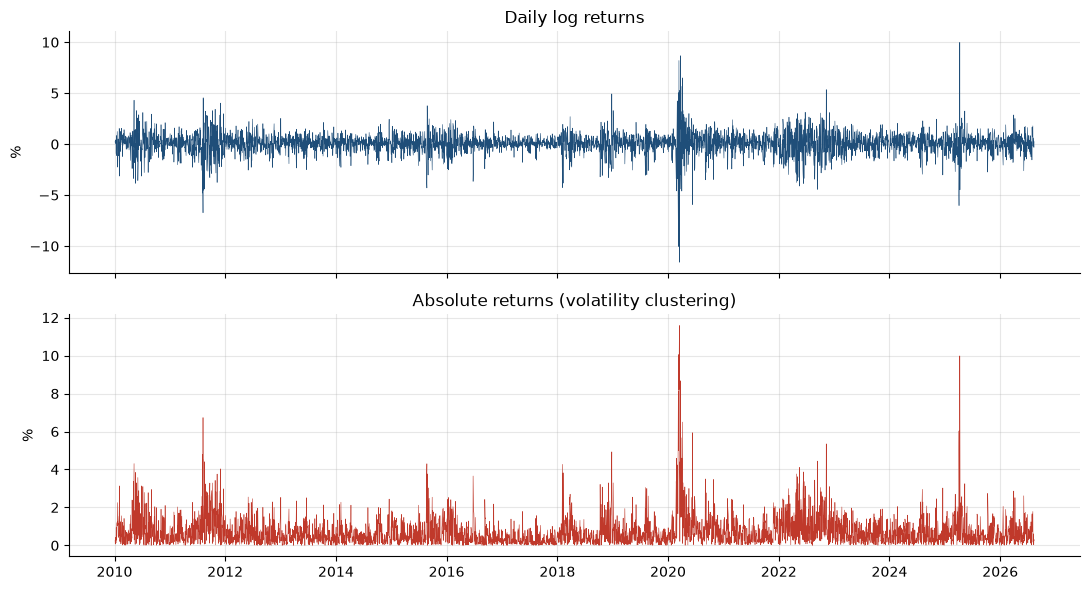

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(r.index, r * 100, lw=0.4, color="#1f4e79")
axes[0].set_title("Daily log returns"); axes[0].set_ylabel("%")
axes[1].plot(r.index, r.abs() * 100, lw=0.4, color="#c0392b")
axes[1].set_title("Absolute returns (volatility clustering)"); axes[1].set_ylabel("%")
plt.tight_layout()

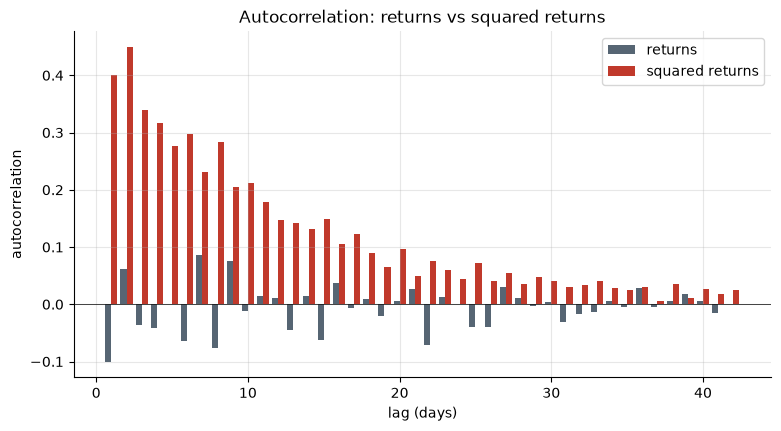

In [6]:
lags = range(1, 43)
acf_r = [r.autocorr(l) for l in lags]
acf_r2 = [(r**2).autocorr(l) for l in lags]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar([l - 0.2 for l in lags], acf_r, width=0.4, label="returns", color="#566573")
ax.bar([l + 0.2 for l in lags], acf_r2, width=0.4, label="squared returns", color="#c0392b")
ax.axhline(0, color="black", lw=0.5)
ax.set_title("Autocorrelation: returns vs squared returns")
ax.set_xlabel("lag (days)"); ax.set_ylabel("autocorrelation"); ax.legend();